In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [2]:
data = fetch_california_housing()
X, y = data.data, data.target

y = y.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.transform(X_test)

sc_y = StandardScaler()
y_train = sc_y.fit_transform(y_train)
y_test = sc_y.transform(y_test)

print("Train size:", X_train.shape[0], " | Features:", X_train.shape[1])

Train size: 16512  | Features: 8


In [3]:
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def linear(z):
    return z

def linear_deriv(z):
    return np.ones_like(z)

def apply_dropout(a, rate, training=True):
    if not training or rate == 0:
        return a, np.ones_like(a)
    mask = (np.random.rand(*a.shape) > rate).astype(float)
    mask = mask / (1 - rate)
    return a * mask, mask

In [4]:
def init_weights(sizes):
    W, b = [], []
    for i in range(len(sizes) - 1):
        W.append(np.random.randn(sizes[i], sizes[i+1]) * np.sqrt(2 / sizes[i]))
        b.append(np.zeros((1, sizes[i+1])))
    return W, b

In [5]:
def forward(X, W, b, drop=0.0, training=True):
    acts = [X]
    zvals = []
    masks = []

    for i in range(len(W) - 1):
        z = acts[-1] @ W[i] + b[i]
        zvals.append(z)
        a, mask = apply_dropout(relu(z), drop, training)
        acts.append(a)
        masks.append(mask)

    z = acts[-1] @ W[-1] + b[-1]
    zvals.append(z)
    acts.append(linear(z))

    return acts, zvals, masks

In [6]:
def backward(X, y, acts, zvals, W, masks, lam=0.0):
    m = X.shape[0]
    gW = [None] * len(W)
    gb = [None] * len(W)

    delta = (acts[-1] - y) * linear_deriv(zvals[-1])
    gW[-1] = acts[-2].T @ delta / m + (lam / m) * W[-1]
    gb[-1] = np.sum(delta, axis=0, keepdims=True) / m

    for i in range(len(W) - 2, -1, -1):
        delta = (delta @ W[i+1].T) * relu_deriv(zvals[i]) * masks[i]
        gW[i] = acts[i].T @ delta / m + (lam / m) * W[i]
        gb[i] = np.sum(delta, axis=0, keepdims=True) / m

    return gW, gb

In [7]:
def init_adam(W, b):
    mW = [np.zeros_like(w) for w in W]
    vW = [np.zeros_like(w) for w in W]
    mb = [np.zeros_like(x) for x in b]
    vb = [np.zeros_like(x) for x in b]
    return mW, vW, mb, vb

def adam_step(W, b, gW, gb, mW, vW, mb, vb, t, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    for i in range(len(W)):
        mW[i] = beta1 * mW[i] + (1 - beta1) * gW[i]
        vW[i] = beta2 * vW[i] + (1 - beta2) * gW[i]**2
        mb[i] = beta1 * mb[i] + (1 - beta1) * gb[i]
        vb[i] = beta2 * vb[i] + (1 - beta2) * gb[i]**2

        mW_h = mW[i] / (1 - beta1**t)
        vW_h = vW[i] / (1 - beta2**t)
        mb_h = mb[i] / (1 - beta1**t)
        vb_h = vb[i] / (1 - beta2**t)

        W[i] -= lr * mW_h / (np.sqrt(vW_h) + eps)
        b[i] -= lr * mb_h / (np.sqrt(vb_h) + eps)

    return W, b, mW, vW, mb, vb

In [8]:
def mse(pred, true):
    return np.mean((pred - true)**2)

def reg_loss(pred, true, W, lam):
    return mse(pred, true) + (lam / (2 * true.shape[0])) * sum(np.sum(w**2) for w in W)

def train(X, y, sizes, epochs=300, lr=0.001, batch_size=64, lam=0.01, drop=0.1):
    W, b = init_weights(sizes)
    mW, vW, mb, vb = init_adam(W, b)
    hist = []
    t = 0

    for ep in range(epochs):
        idx = np.random.permutation(X.shape[0])
        Xs, ys = X[idx], y[idx]

        for s in range(0, X.shape[0], batch_size):
            Xb, yb = Xs[s:s+batch_size], ys[s:s+batch_size]
            acts, zvals, masks = forward(Xb, W, b, drop, training=True)
            gW, gb = backward(Xb, yb, acts, zvals, W, masks, lam)
            t += 1
            W, b, mW, vW, mb, vb = adam_step(W, b, gW, gb, mW, vW, mb, vb, t, lr)

        acts, _, _ = forward(X, W, b, 0.0, training=False)
        hist.append(reg_loss(acts[-1], y, W, lam))

        if (ep + 1) % 50 == 0:
            print(f"Epoch {ep+1}/{epochs}  Loss: {hist[-1]:.4f}")

    return W, b, hist

In [9]:
sizes = [8, 64, 32, 1]

W_best, b_best, loss_hist = train(X_train, y_train, sizes, epochs=300, lr=0.001, batch_size=64, lam=0.01, drop=0.1)

Epoch 50/300  Loss: 0.2107
Epoch 100/300  Loss: 0.1916
Epoch 150/300  Loss: 0.1789
Epoch 200/300  Loss: 0.1759
Epoch 250/300  Loss: 0.1729
Epoch 300/300  Loss: 0.1732


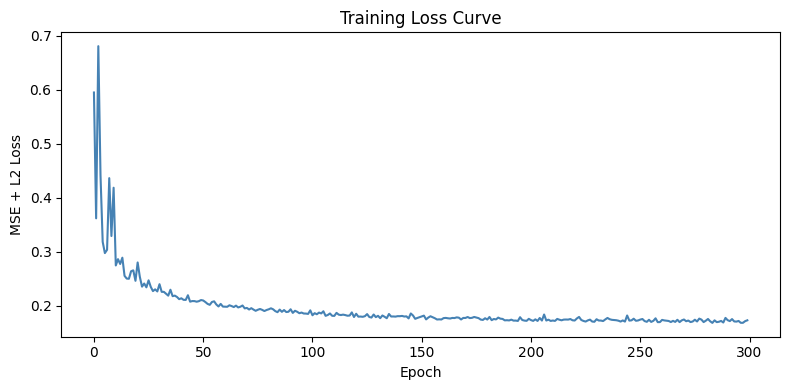

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(loss_hist, color='steelblue')
plt.xlabel("Epoch")
plt.ylabel("MSE + L2 Loss")
plt.title("Training Loss Curve")
plt.tight_layout()
plt.show()

In [11]:
acts, _, _ = forward(X_test, W_best, b_best, 0.0, training=False)
y_pred = sc_y.inverse_transform(acts[-1])
y_actual = sc_y.inverse_transform(y_test)

print(f"Test MSE: {mean_squared_error(y_actual, y_pred):.4f}")

Test MSE: 0.2609


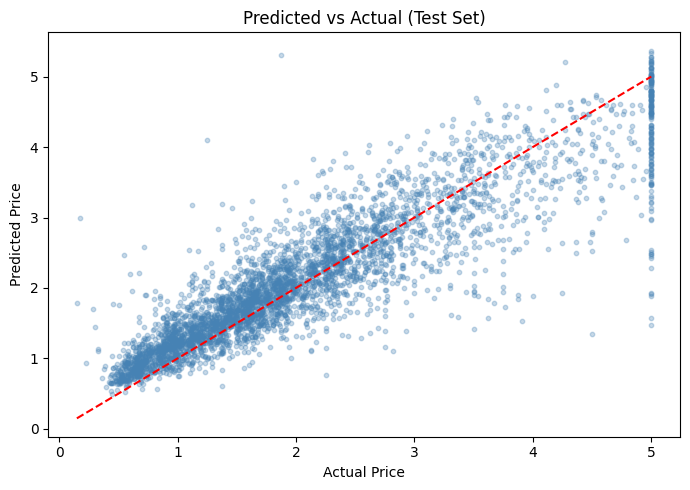

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(y_actual, y_pred, alpha=0.3, s=10, color='steelblue')
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=1.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual (Test Set)")
plt.tight_layout()
plt.show()

In [13]:
def run_exp(X_tr, y_tr, X_val, y_val, sizes, epochs=300, lr=0.001, batch_size=64, lam=0.0, drop=0.0, log_every=10):
    W, b = init_weights(sizes)
    mW, vW, mb, vb = init_adam(W, b)
    tr_hist, val_hist = [], []
    t = 0

    for ep in range(epochs):
        idx = np.random.permutation(X_tr.shape[0])
        Xs, ys = X_tr[idx], y_tr[idx]

        for s in range(0, X_tr.shape[0], batch_size):
            Xb, yb = Xs[s:s+batch_size], ys[s:s+batch_size]
            acts, zvals, masks = forward(Xb, W, b, drop, training=True)
            gW, gb = backward(Xb, yb, acts, zvals, W, masks, lam)
            t += 1
            W, b, mW, vW, mb, vb = adam_step(W, b, gW, gb, mW, vW, mb, vb, t, lr)

        if (ep + 1) % log_every == 0:
            a_tr, _, _ = forward(X_tr, W, b, 0.0, training=False)
            a_val, _, _ = forward(X_val, W, b, 0.0, training=False)
            tr_hist.append(mse(a_tr[-1], y_tr))
            val_hist.append(mse(a_val[-1], y_val))

    return tr_hist, val_hist


l2_tests = [0.0, 0.05, 5.0]
dr_tests  = [0.0, 0.25, 0.65]

l2_runs = {}
for lv in l2_tests:
    tr, val = run_exp(X_train, y_train, X_test, y_test, sizes, epochs=300, lr=0.001, lam=lv, drop=0.0)
    l2_runs[lv] = (tr, val)
    print(f"L2={lv} done")

dr_runs = {}
for dv in dr_tests:
    tr, val = run_exp(X_train, y_train, X_test, y_test, sizes, epochs=300, lr=0.001, lam=0.0, drop=dv)
    dr_runs[dv] = (tr, val)
    print(f"Dropout={dv} done")

L2=0.0 done
L2=0.05 done
L2=5.0 done
Dropout=0.0 done
Dropout=0.25 done
Dropout=0.65 done


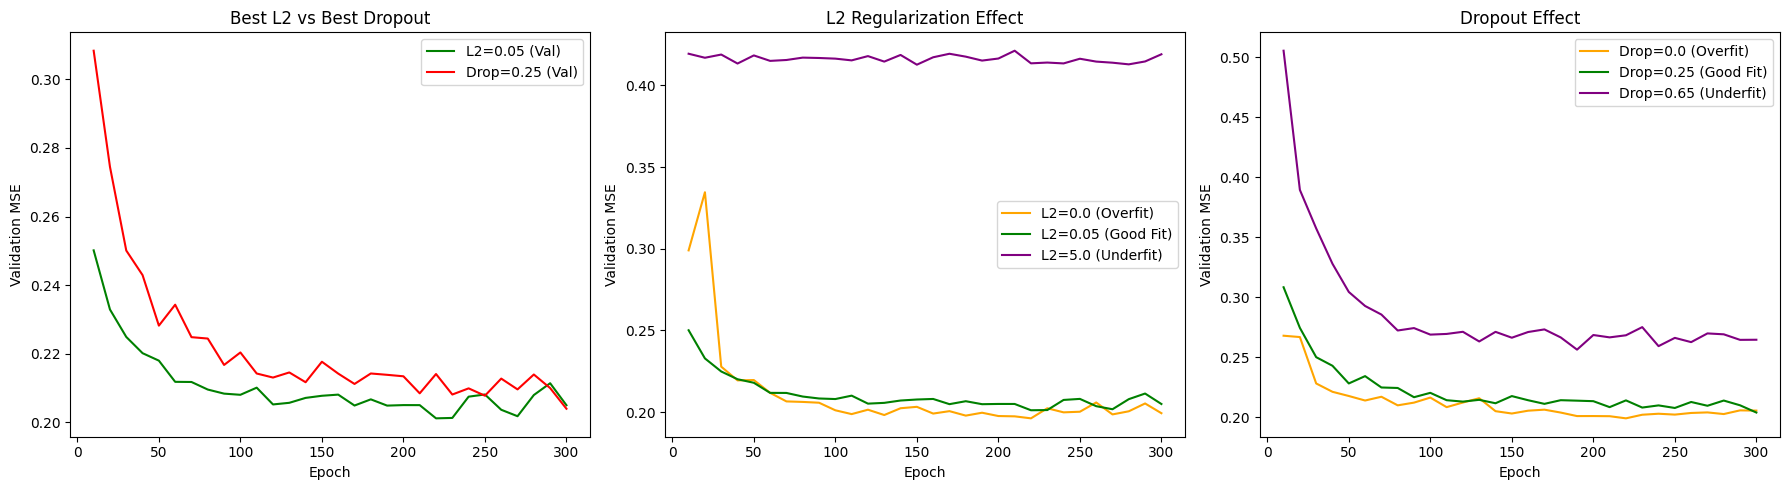

In [14]:
ep_ax  = list(range(10, 301, 10))
colors = ['orange', 'green', 'purple']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(ep_ax, l2_runs[0.05][1], label='L2=0.05 (Val)',  color='green')
axes[0].plot(ep_ax, dr_runs[0.25][1], label='Drop=0.25 (Val)', color='red')
axes[0].set_title('Best L2 vs Best Dropout')
axes[0].legend()

labels_l2 = ['L2=0.0 (Overfit)', 'L2=0.05 (Good Fit)', 'L2=5.0 (Underfit)']
for lv, c, lbl in zip(l2_tests, colors, labels_l2):
    axes[1].plot(ep_ax, l2_runs[lv][1], label=lbl, color=c)
axes[1].set_title('L2 Regularization Effect')
axes[1].legend()

labels_dr = ['Drop=0.0 (Overfit)', 'Drop=0.25 (Good Fit)', 'Drop=0.65 (Underfit)']
for dv, c, lbl in zip(dr_tests, colors, labels_dr):
    axes[2].plot(ep_ax, dr_runs[dv][1], label=lbl, color=c)
axes[2].set_title('Dropout Effect')
axes[2].legend()

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation MSE')

plt.tight_layout()
plt.show()

Comparison of regularization and droupout:

L2 Regularization

L2 adds a penalty equal to the sum of squared weights to the loss. This stops the network from assigning too much weight to any single feature.
- λ = 0.0 — No penalty. Weights can grow large to memorize training noise, leading to overfitting.
- λ = 0.05 — Moderate penalty. Weights stay controlled and the model generalizes well (good fit).
- λ = 5.0 — Excessive penalty. Weights are crushed toward zero and the model cannot learn patterns (underfitting).

Dropout

Dropout randomly disables neurons during each training step. This forces the network to distribute learning across many neurons rather than depending on a few.
- Rate = 0.0 — No neurons dropped. Strong co-adaptation between neurons causes overfitting.
- Rate = 0.25 — A moderate fraction disabled each step. Co-adaptation is broken and the model generalizes (good fit).
- Rate = 0.65 — Too many neurons disabled. Too little information flows per step and the model cannot converge (underfitting).
***